In [44]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib
matplotlib.rcParams.update({'font.size': 13})
matplotlib.rcParams['lines.linewidth'] = 2
import scipy.optimize as opt


light_green = (0.4, 0.8, 0.2)
dark_purple = (0.4, 0.3, 0.7)
raspberry_pink = (1, 0, 0.5)

In [ ]:
# калибровка винта

k = 910/1023 #mkm/del
sigma_k = k * ((1/100)**2 + (1/1023)**2) ** 0.5
center = 593.61 #del
sigma_center = 0.06 #del
sigma_sc = 0.5 #del

# радиус темного пятна
r_spot = (735 - 450) * k / 2 #mkm
sigma_r_spot = (2*sigma_sc**2/(735 - 450)**2 + (sigma_k/k)**2)**0.5 * r_spot #mkm
k, sigma_k
r_spot, sigma_r_spot

(126.75953079178885, 1.311892434074347)

In [12]:
# погрешности радиусов в делениях
sigma_r = (sigma_center**2 + sigma_sc**2)**0.5
data = pd.read_excel("измерения.xlsx", sheet_name="желтый темные светлые")
data['n, номер кольца'] = data['n, номер кольца'].astype(int)

# пересчет радиусов
data['r_d_min'] = abs(data['r_d_min'] - center)
data['r_d_max'] = abs(data['r_d_max'] - center)
data['r_l_min'] = abs(data['r_l_min'] - center)
data['r_l_max'] = abs(data['r_l_max'] - center)

In [13]:
# в делениях
data['r_d'] = (data['r_d_min']+data['r_d_max'])/2
data['sigma_r_d'] = (((data['r_d_max']-data['r_d_min'])/2)**2 + sigma_r**2)**0.5

data['r_l'] = (data['r_l_min']+data['r_l_max'])/2
data['sigma_r_l'] = (((data['r_l_max']-data['r_l_min'])/2)**2 + sigma_r**2)**0.5

# в мкм
data['r_d, mkm'] = data['r_d'] * k
data['sigma_r_d, mkm'] = ((data['sigma_r_d']/data['r_d'])**2+(sigma_k/k)**2)**0.5 * data['r_d, mkm']

data['r_l, mkm'] = data['r_l'] * k
data['sigma_r_l, mkm'] = ((data['sigma_r_l']/data['r_l'])**2+(sigma_k/k)**2)**0.5 * data['r_l, mkm']

data


,"n, номер кольца",r_d_min,r_d_max,r_l_min,r_l_max,r_d,sigma_r_d,r_l,sigma_r_l,"r_d, mkm","sigma_r_d, mkm","r_l, mkm","sigma_r_l, mkm"
0,-15,519.6,526.6,506.6,519.6,523.1,3.570714,513.1,6.538348,465.318671,5.652247,456.423265,7.406659
1,-14,501.6,506.6,490.6,501.6,504.1,2.598076,496.1,5.545268,448.417400,5.063705,441.301075,6.632698
2,-13,483.6,490.6,473.6,483.6,487.1,3.570714,478.6,5.049752,433.295210,5.389130,425.734115,6.202890
3,-12,465.6,473.6,452.6,465.6,469.6,4.062019,459.1,6.538348,417.728250,5.538284,408.388074,7.117919
4,-11,448.6,452.6,437.6,448.6,450.6,2.121320,443.1,5.545268,400.826979,4.447529,394.155425,6.325839
5,-10,429.6,437.6,419.6,429.6,433.6,4.062019,424.6,5.049752,385.704790,5.298597,377.698925,5.880448
6,-9,407.6,419.6,397.6,407.6,413.6,6.041523,402.6,5.049752,367.913978,6.522823,358.129032,5.755510
7,-8,387.6,397.6,375.6,387.6,392.6,5.049752,381.6,6.041523,349.233627,5.700058,339.448680,6.365096
8,-7,364.6,375.6,352.6,364.6,370.1,5.545268,358.6,6.041523,329.218964,5.939193,318.989247,6.257352
9,-6,344.6,352.6,331.6,344.6,348.6,4.062019,338.1,6.538348,310.093842,4.771149,300.753666,6.554314


In [41]:
pd.set_option('display.float_format', '{:.0f}'.format)
data[['n, номер кольца', 'r_d, mkm', 'sigma_r_d, mkm', 'r_l', 'sigma_r_l, mkm']]

,"n, номер кольца","r_d, mkm","sigma_r_d, mkm",r_l,"sigma_r_l, mkm"
0,-15,465,6,513,7
1,-14,448,5,496,7
2,-13,433,5,479,6
3,-12,418,6,459,7
4,-11,401,4,443,6
5,-10,386,5,425,6
6,-9,368,7,403,6
7,-8,349,6,382,6
8,-7,329,6,359,6
9,-6,310,5,338,7


# Проверка, что слева и справа кольца одинаковых радиусов

C:\Users\user\AppData\Local\Temp\ipykernel_316\244206513.py:11: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(data["n, номер кольца"].iloc[15:], data['r_d, mkm'].iloc[15:],


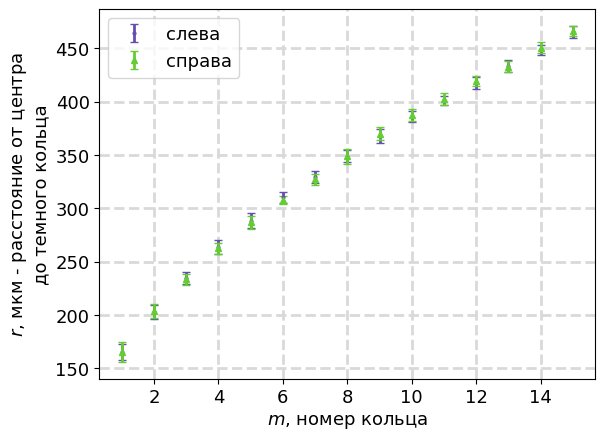

In [62]:
plt.grid(c = (0.85, 0.85, 0.85), ls = '--', lw = 2, zorder = 0)

plt.errorbar(abs(data["n, номер кольца"]).iloc[:15], data['r_d, mkm'].iloc[:15], 
             yerr = data['sigma_r_d, mkm'].iloc[:15], 
             fmt = 'o', 
             capsize=3, 
             markersize = 2, 
             label = 'слева',
             color = dark_purple,
             zorder = 5)
plt.errorbar(data["n, номер кольца"].iloc[15:], data['r_d, mkm'].iloc[15:], 
             yerr = data['sigma_r_d, mkm'].iloc[15:], 
             marker = '^',
             fmt = 'o', 
             capsize=3, 
             markersize = 4, 
             label = 'справа',
             color = light_green,
             zorder = 5)

plt.ylabel(r'$r$, мкм - расстояние от центра'+'\nдо темного кольца')
plt.xlabel(r'$m$, номер кольца')
plt.legend()
plt.savefig('pics/backlash.png', dpi = 300, bbox_inches='tight')

# Расчет усредненных радиусов колец

In [64]:
def mean_sigma(x):
    return np.sqrt((x**2).sum()) / len(x)

data_avg = (
    data.groupby(abs(data['n, номер кольца']))
      .agg({
          'r_d, mkm': 'mean',
          'r_l, mkm': 'mean',
          'sigma_r_d, mkm': mean_sigma,
          'sigma_r_l, mkm': mean_sigma
      })
      .reset_index()
      .rename(columns={'abs_n': 'n'})
)
data_avg[['n, номер кольца', 'r_d, mkm', 'sigma_r_d, mkm', 'r_l, mkm', 'sigma_r_l, mkm']]


,"n, номер кольца","r_d, mkm","sigma_r_d, mkm","r_l, mkm","sigma_r_l, mkm"
0,1,165,6,142,11
1,2,203,5,185,8
2,3,234,4,219,7
3,4,263,4,248,7
4,5,288,5,275,5
5,6,309,3,300,5
6,7,328,4,318,5
7,8,349,4,338,5
8,9,369,4,359,4
9,10,387,4,378,4


In [55]:
def linear(x, k, b):
    return k*x + b
popt, pcov = opt.curve_fit(linear, 
                             data_avg["n, номер кольца"], 
                             data_avg["r_d, mkm"]**2, 
                             sigma = 2*data_avg["sigma_r_d, mkm"]*data_avg["r_d, mkm"], 
                             absolute_sigma = True)
k_d = popt[0]/1e6 #mm^2
b_d = popt[1]/1e6 #mm^2
sigma_k_d = pcov[0][0]**0.5/1e6 #mm^2
sigma_b_d = pcov[1][1]**0.5/1e6 #mm^2

popt, pcov = opt.curve_fit(linear, 
                             data_avg["n, номер кольца"], 
                             data_avg["r_l, mkm"]**2, 
                             sigma = 2*data_avg["sigma_r_l, mkm"]*data_avg["r_l, mkm"], 
                             absolute_sigma = True)
k_l = popt[0]/1e6 #mm^2
b_l = popt[1]/1e6 #mm^2
sigma_k_l = pcov[0][0]**0.5/1e6 #mm^2
sigma_b_l = pcov[1][1]**0.5/1e6 #mm^2

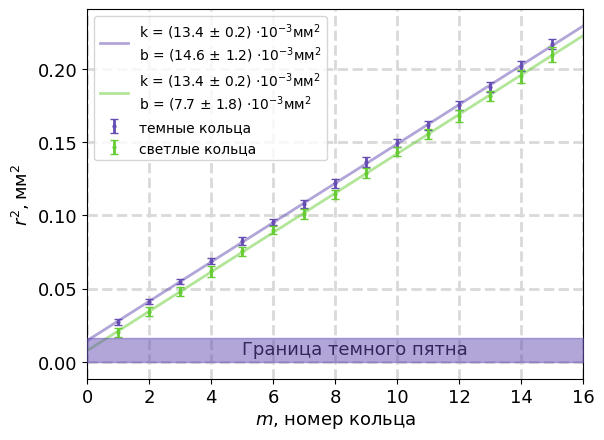

In [65]:
plt.grid(c = (0.85, 0.85, 0.85), ls = '--', lw = 2, zorder = 0)

n_th = np.linspace(0, 16)
plt.plot(n_th, k_d * n_th + b_d, c = dark_purple, alpha = 0.5, 
         label = (f'k = ({k_d * 1e3:.1f} ' + r'$\pm$' + f' {sigma_k_d * 1e3:.1f}) ' + r'$\cdot 10^{-3}\text{мм}^2$' + "\n"
                  f'b = ({b_d * 1e3:.1f} ' + r'$\pm$' + f' {sigma_b_d * 1e3:.1f}) ' + r'$\cdot 10^{-3}\text{мм}^2$'))
plt.errorbar(data_avg['n, номер кольца'], data_avg['r_d, mkm']**2/1e6, 
             yerr = 2*data_avg['r_d, mkm'] * data_avg['sigma_r_d, mkm']/1e6, 
             fmt = 'o', 
             capsize=3, 
             markersize = 2, 
             label = 'темные кольца',
             color = dark_purple,
             zorder = 5)

plt.plot(n_th, k_l * n_th + b_l, c = light_green, alpha = 0.5, 
         label = (f'k = ({k_l * 1e3:.1f} ' + r'$\pm$' + f' {sigma_k_l * 1e3:.1f}) ' + r'$\cdot 10^{-3}\text{мм}^2$' + "\n"
                  f'b = ({b_l * 1e3:.1f} ' + r'$\pm$' + f' {sigma_b_l * 1e3:.1f}) ' + r'$\cdot 10^{-3}\text{мм}^2$'))
plt.errorbar(data_avg['n, номер кольца'], data_avg['r_l, mkm']**2/1e6, 
             yerr = 2*data_avg['r_l, mkm'] * data_avg['sigma_r_l, mkm']/1e6, 
             fmt = 'o', 
             capsize=3, 
             markersize = 2, 
             label = 'светлые кольца',
             color = light_green,
             zorder = 5)

plt.fill_between([0, 16], [0, 0], [r_spot**2/1e6, r_spot**2/1e6], color = dark_purple, alpha = 0.5, zorder = 10)
plt.text(5, 0.005, "Граница темного пятна")
plt.ylabel(r'$r^2, \text{мм}^2$')
plt.xlabel(r'$m$, номер кольца')
plt.xlim(0, 16)
plt.legend(loc = 'upper left', prop={'size': 10})
plt.savefig('pics/dark and light.png', dpi = 300)

In [17]:
backlash = pd.read_excel("измерения.xlsx", sheet_name="люфт")[["n", "left_outer", "left_inner", "right_inner", "right_outer"]].dropna()
backlash["n"] = backlash["n"].astype(int)
backlash['left'] = (backlash['left_outer'] + backlash['left_inner'])/2
backlash['sigma_left'] = (backlash['left_outer'] - backlash['left_inner'])/2
backlash['right'] = (backlash['right_outer'] + backlash['right_inner'])/2
backlash['sigma_right'] = (backlash['right_outer'] - backlash['right_inner'])/2

# Расчет радиуса кривизны и диаметра контакта

In [67]:
lambda_y = 578 * 1e-6 #mm
k_avg = (k_d + k_l) / 2
sigma_k_avg = (((k_d - k_l)/2)**2 + sigma_k_d**2 + sigma_k_l**2)**0.5
k_avg/lambda_y, sigma_k_avg/lambda_y

(23.2217001361373, 0.4585673143247665)

In [68]:
# диаметр контакта
dd = 2 * b_d**0.5
dl = 2 * (b_l + k_avg/2)**0.5

sigma_dd = sigma_b_d/b_d**0.5
sigma_dl = (sigma_b_l**2 + (sigma_k_avg/2)**2)**0.5/(b_l + k_avg/2)**0.5

d0 = (dd + dl)/2
sigma_d0 = (((dd - dl)/2)**2 + sigma_dd**2 + sigma_dl**2)**0.5
d0, sigma_d0


(0.24071076608586361, 0.017644803118245955)